In [5]:
import sys
from pathlib import Path

def _find_scripts_dir():
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        for cand in (base / "scripts", base,
                     *sorted(base.glob("*/scripts")), *sorted(base.glob("*/*/scripts"))):
            if (cand / "project_paths.py").is_file():
                return cand
    raise FileNotFoundError(
        "scripts/project_paths.py not found. Open this notebook from inside the "
        "cloned repository, or point the kernel's working directory at it."
    )

sys.path.insert(0, str(_find_scripts_dir()))
from project_config import *
import numpy as np, pandas as pd
model_df = load_model_df()
y = model_df["phq9"]
assert len(ACOUSTIC) == 72

# Feature matrices used throughout. Raw values: every model here is a RandomForest,
# which is invariant to feature scaling, so no standardisation is needed.
X_demo     = model_df[DEMO]
X_psych    = model_df[PSYCH]
X_clinical = model_df[CLINICAL]
X_acoustic = model_df[ACOUSTIC]

In [6]:
# Computing MDI and permutation importance for the Random Forest model (demographic values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X_demo, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  age                0.510167
education_years    0.398915
gender             0.090918
dtype: float64
Permutation Importances:  education_years    1.018335
age                0.267131
gender             0.049465
dtype: float64
Standard Deviations:  education_years    0.491660
age                0.257432
gender             0.076392
dtype: float64


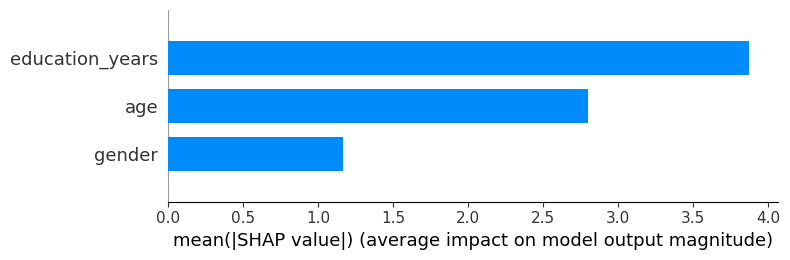

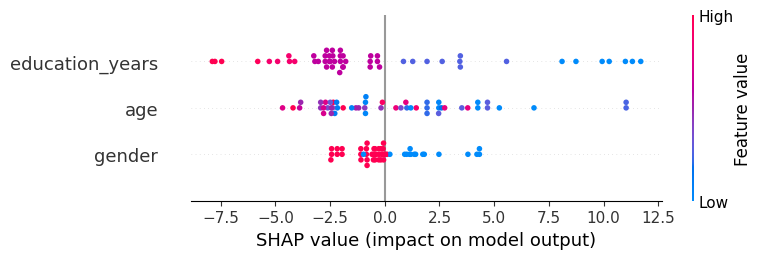

In [7]:
# SHAP for Random Forest model (demo values)
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_demo, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_demo)

shap.summary_plot(shap_values, X_demo, plot_type="bar") # global ranking
shap.summary_plot(shap_values, X_demo) # beeswarm plot: direction + magnitude

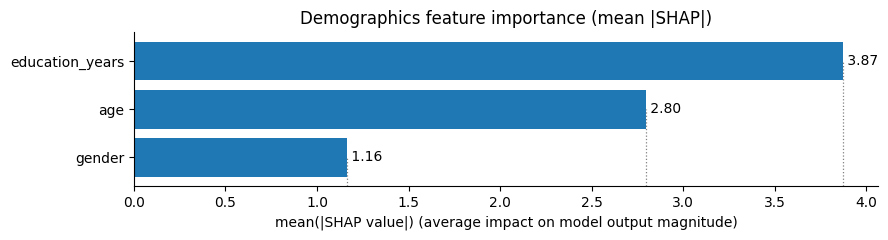

In [8]:
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = X_demo
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)
feats = np.array(X.columns)[order]
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)          # vertical dotted line -> x-axis
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)  # exact value at bar tip
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

# NO set_xticks -> the default scale (0, 1, 2, 3, 4 ...) stays
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title("Demographics feature importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "demo_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()



In [9]:
# Computing MDI and permutation importance for the Random Forest model (psych values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X_psych, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  gad7      0.874053
SSRS      0.050535
LES       0.049115
ctq_sf    0.026297
dtype: float64
Permutation Importances:  gad7      1.506228
LES       0.028235
ctq_sf   -0.004543
SSRS     -0.029478
dtype: float64
Standard Deviations:  gad7      0.561477
LES       0.017822
ctq_sf    0.010864
SSRS      0.020792
dtype: float64


In [10]:
# Computing MDI and permutation importance for the Random Forest model (clinical values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X_clinical, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  gad7               0.864075
SSRS               0.038586
LES                0.036944
age                0.028786
education_years    0.016079
ctq_sf             0.012834
gender             0.002696
dtype: float64
Permutation Importances:  gad7               1.381707
LES                0.026874
age               -0.001335
ctq_sf            -0.001429
gender            -0.003010
education_years   -0.005224
SSRS              -0.028022
dtype: float64
Standard Deviations:  gad7               0.511547
LES                0.017534
age                0.010347
ctq_sf             0.005346
gender             0.001532
education_years    0.006190
SSRS               0.016879
dtype: float64


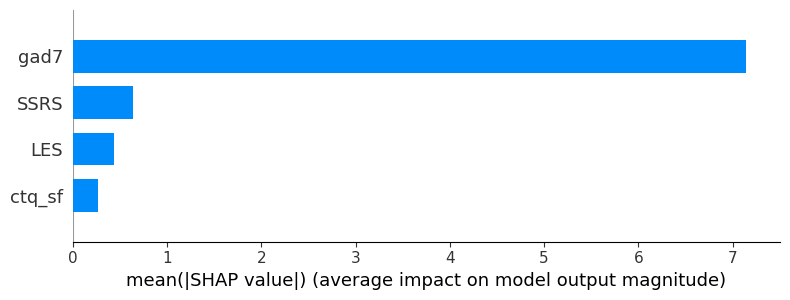

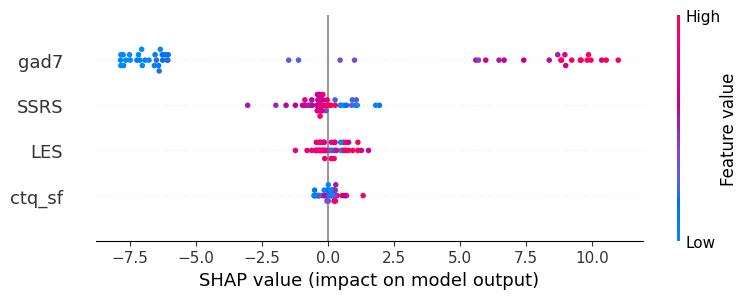

In [11]:
# SHAP for Random Forest model (psych values)
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_psych, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_psych)

shap.summary_plot(shap_values, X_psych, plot_type="bar") # global ranking
shap.summary_plot(shap_values, X_psych) # beeswarm plot: direction + magnitude

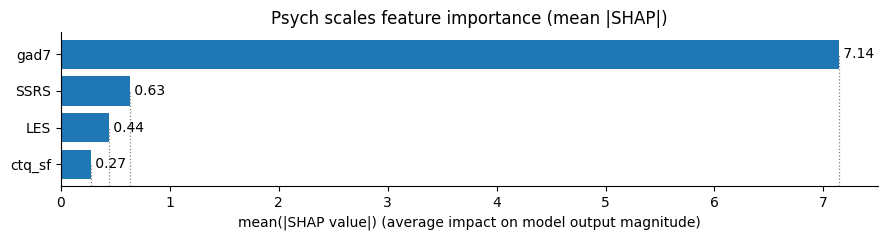

In [12]:
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[PSYCH] 
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)
feats = np.array(X.columns)[order]
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)          # vertical dotted line -> x-axis
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)  # exact value at bar tip
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

# NO set_xticks -> the default scale (0, 1, 2, 3, 4 ...) stays
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title("Psych scales feature importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "psych_shap_plot.png", dpi=300, bbox_inches="tight")
plt.show()


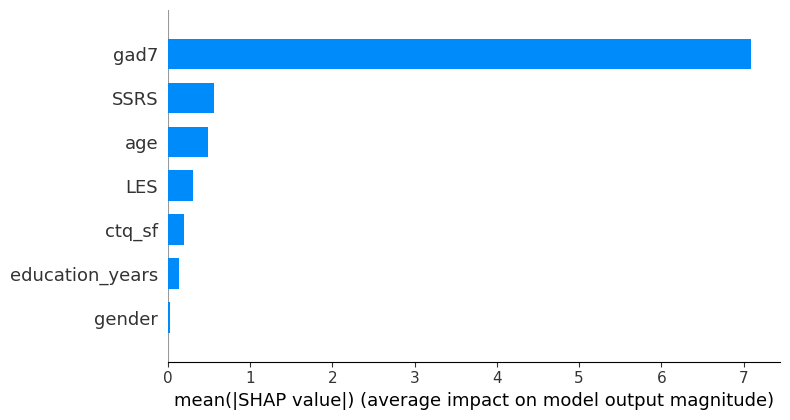

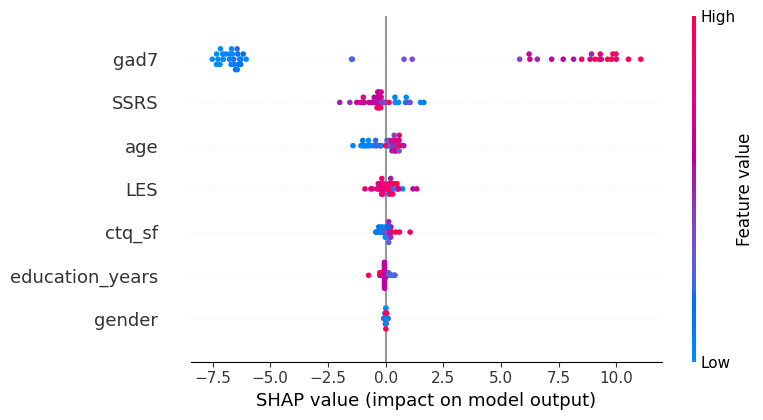

In [13]:
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_clinical, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_clinical)

shap.summary_plot(shap_values, X_clinical, plot_type="bar") # global ranking
shap.summary_plot(shap_values, X_clinical) # beeswarm plot: direction + magnitude

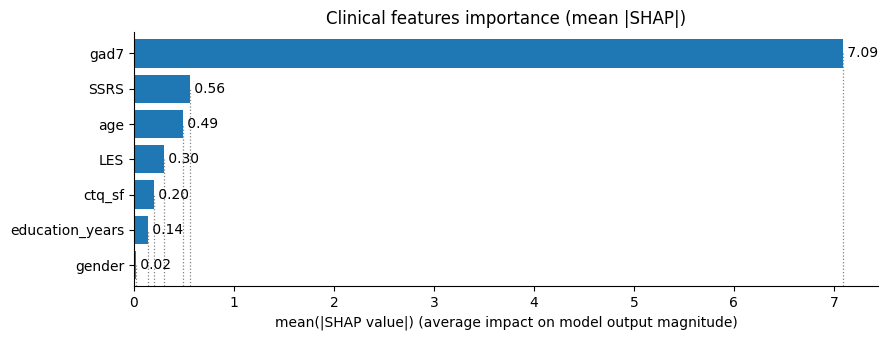

In [14]:
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[CLINICAL] 
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)
feats = np.array(X.columns)[order]
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)          # vertical dotted line -> x-axis
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)  # exact value at bar tip
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

# NO set_xticks -> the default scale (0, 1, 2, 3, 4 ...) stays
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title("Clinical features importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "clinical_shap_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
# MDI + permutation importance for the Random Forest model (top 20 acoustic values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = model_df[ACOUSTIC]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)

perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=SEED, scoring="r2")

imp = pd.DataFrame({
    "category":  [categorize(c) for c in X.columns],   # <-- links feature to its group
    "mdi":       rf.feature_importances_,
    "perm_mean": perm.importances_mean,
    "perm_std":  perm.importances_std,
}, index=X.columns)

top20 = imp.sort_values("mdi", ascending=False).head(20)
print(top20.round(4).to_string())
top20.to_csv(CSV_DIR / "acoustic_top20_importance.csv")


                                              category     mdi  perm_mean  perm_std
spectralFluxV_sma3nz_amean                    Spectral  0.2496     0.1611    0.1586
equivalentSoundLevel_dBp               Loudness/Energy  0.0467    -0.0021    0.0221
logRelF0-H1-A3_sma3nz_amean              Voice quality  0.0340     0.0235    0.0254
F1amplitudeLogRelF0_sma3nz_amean              Formants  0.0329    -0.0200    0.0265
F2frequency_sma3nz_stddevNorm                 Formants  0.0324    -0.0278    0.0273
mfcc2_sma3_stddevNorm                         Spectral  0.0295    -0.0340    0.0094
alphaRatioV_sma3nz_stddevNorm                 Spectral  0.0278     0.0080    0.0293
F1amplitudeLogRelF0_sma3nz_stddevNorm         Formants  0.0277    -0.0174    0.0175
spectralFlux_sma3_amean                       Spectral  0.0276    -0.0040    0.0154
mfcc3V_sma3nz_stddevNorm                      Spectral  0.0261     0.0340    0.0435
spectralFlux_sma3_stddevNorm                  Spectral  0.0239     0.0011   

In [16]:
# Grouped MDI + permutation importance for the Random Forest model (acoustic values)
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = model_df[ACOUSTIC]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)

# feature -> category map
cat_cols = {}
for feat in X.columns:
    cat_cols.setdefault(categorize(feat), []).append(feat)

mdi = pd.Series(rf.feature_importances_, index=X.columns)   # additive -> sum per category is valid

# grouped permutation importance: shuffle the WHOLE category block together, measure R2 drop
rng = np.random.RandomState(SEED)
baseline = r2_score(y_test, rf.predict(X_test))
N_REPEATS = 30

rows = []
for cat, cols in cat_cols.items():
    drops = []
    for _ in range(N_REPEATS):
        Xp = X_test.copy()
        idx = rng.permutation(len(Xp))
        Xp[cols] = X_test[cols].values[idx]          # same row permutation for all cols -> block shuffle
        drops.append(baseline - r2_score(y_test, rf.predict(Xp)))
    rows.append({
        "category": cat,
        "n_features": len(cols),
        "mdi_sum": round(mdi[cols].sum(), 4),
        "group_perm_mean": round(np.mean(drops), 4),   # R2 drop when the whole category is shuffled
        "group_perm_std":  round(np.std(drops), 4),
    })

by_cat = pd.DataFrame(rows).set_index("category").sort_values("group_perm_mean", ascending=False)
by_cat["mdi_%"] = (100 * by_cat["mdi_sum"] / by_cat["mdi_sum"].sum()).round(1)
print(by_cat.to_string())
by_cat.to_csv(CSV_DIR / "acoustic_importance_by_category.csv")


                 n_features  mdi_sum  group_perm_mean  group_perm_std  mdi_%
category                                                                    
Spectral                 33   0.5861           0.2337          0.2348   58.6
Voice quality            10   0.1225           0.1183          0.0549   12.3
Pitch                     2   0.0221           0.0059          0.0089    2.2
Timing/Pauses             6   0.0183          -0.0070          0.0091    1.8
Loudness/Energy           3   0.0726          -0.0113          0.0382    7.3
Formants                 18   0.1783          -0.0365          0.0586   17.8


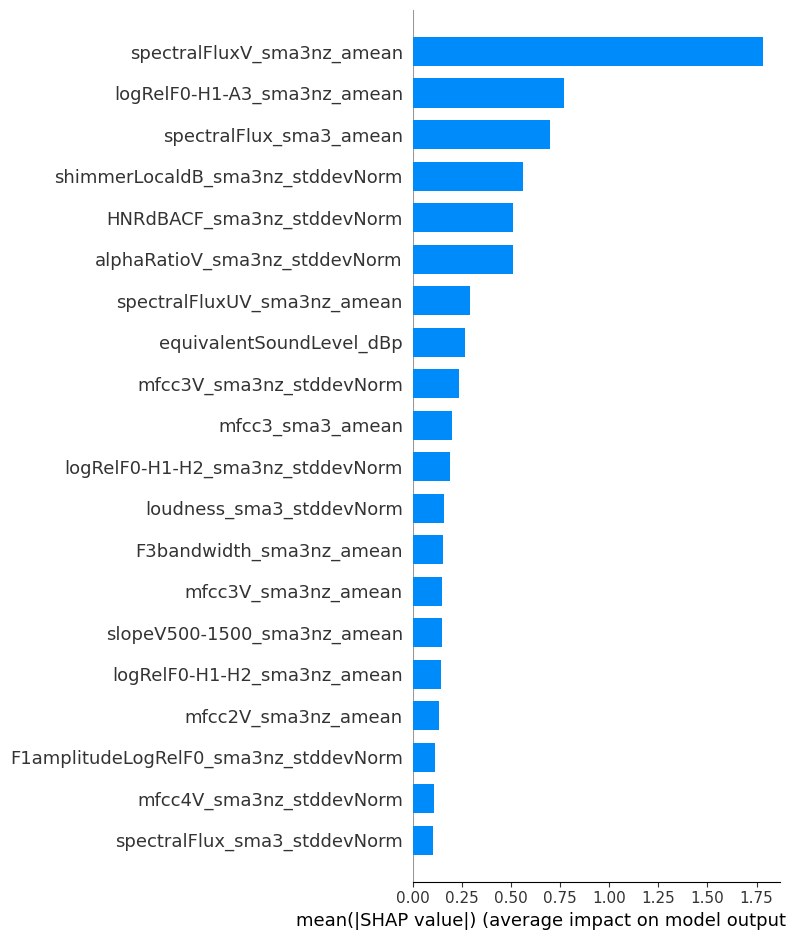

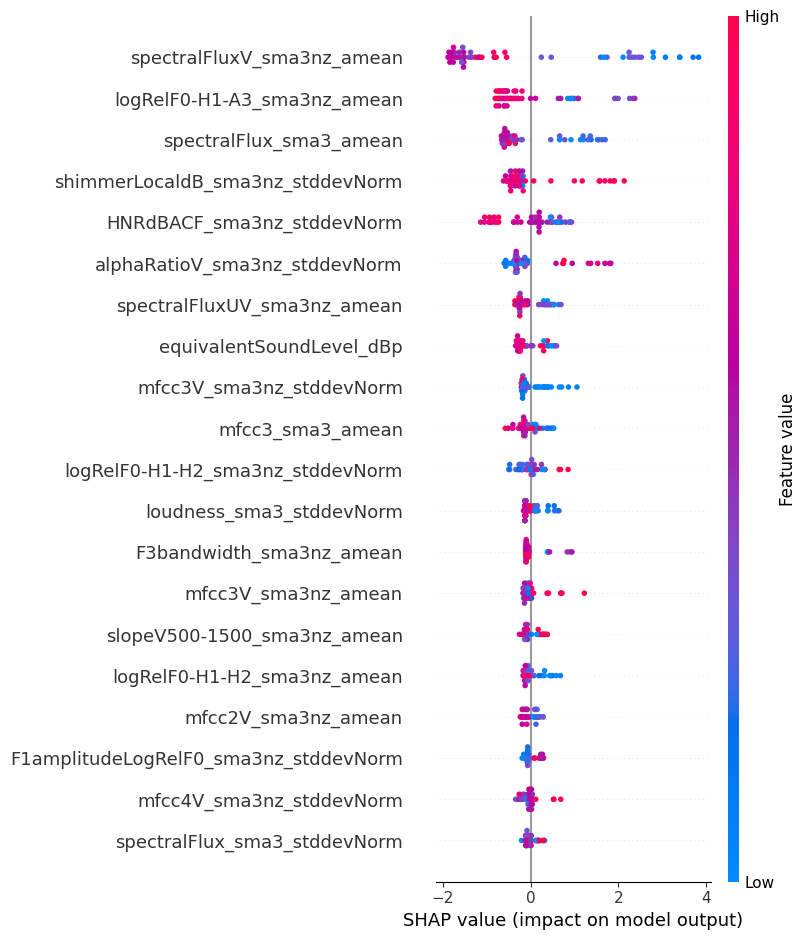

In [17]:
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_acoustic, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_acoustic)

shap.summary_plot(shap_values, X_acoustic, plot_type="bar") # global ranking
shap.summary_plot(shap_values, X_acoustic) # beeswarm plot: direction + magnitude

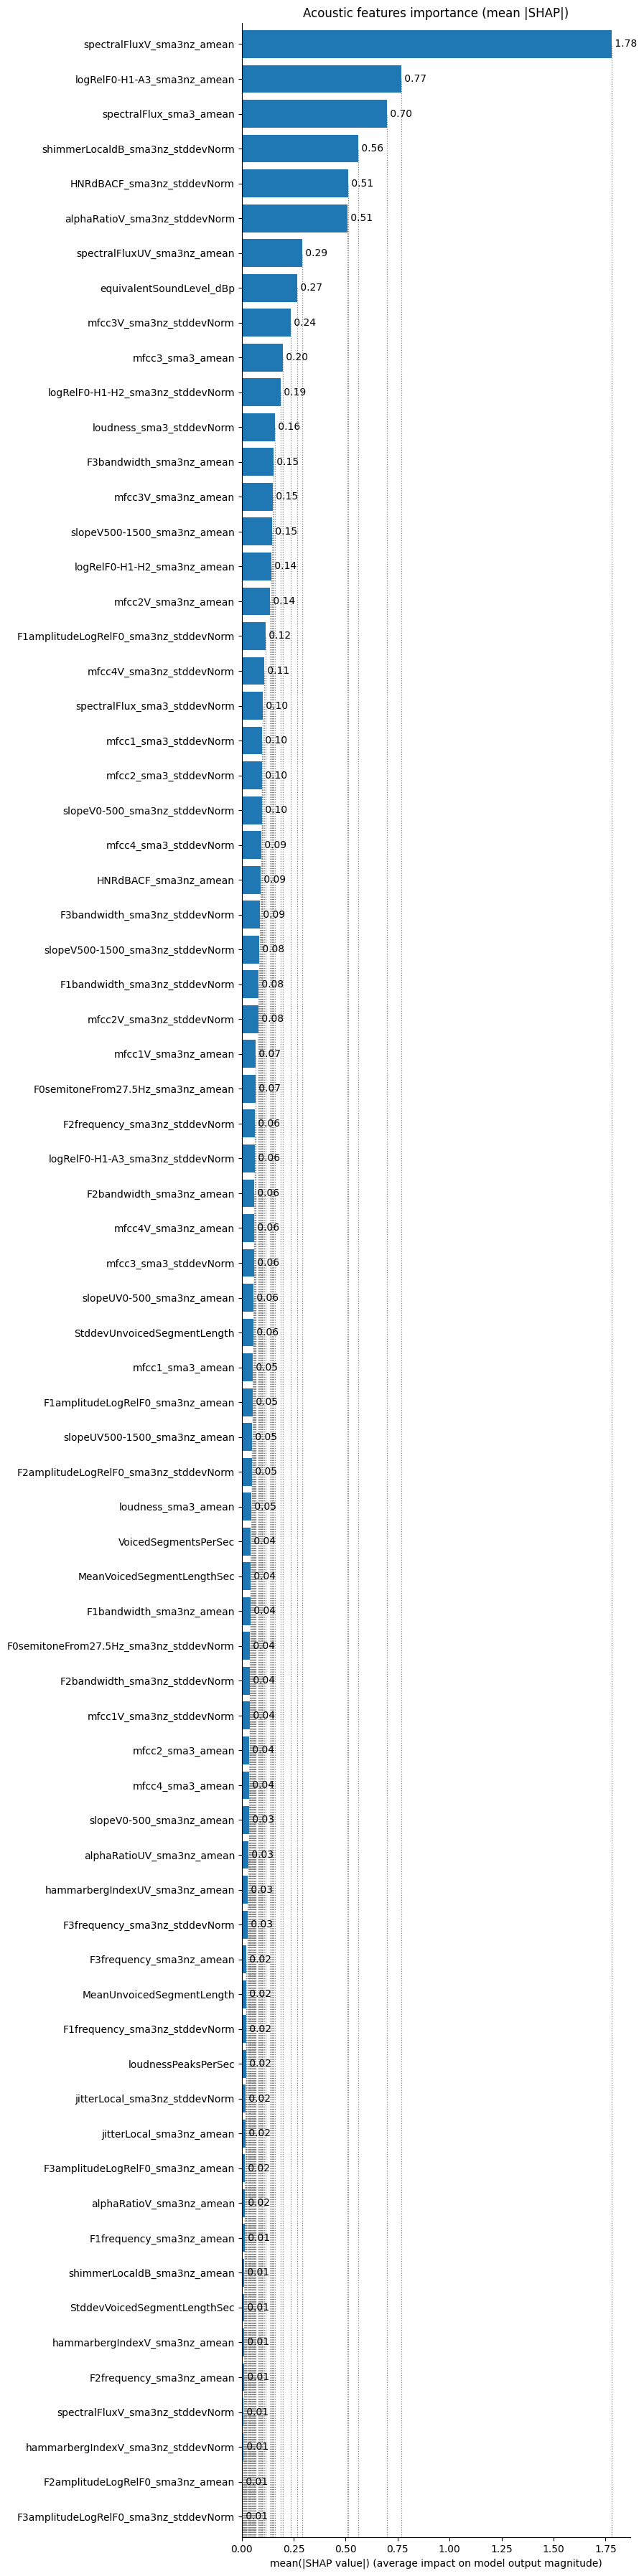

In [18]:
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[ACOUSTIC] 
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)
feats = np.array(X.columns)[order]
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)          # vertical dotted line -> x-axis
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)  # exact value at bar tip
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

# NO set_xticks -> the default scale (0, 1, 2, 3, 4 ...) stays
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title("Acoustic features importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "acoustic_shap_plot.png", dpi=300, bbox_inches="tight")
plt.show()


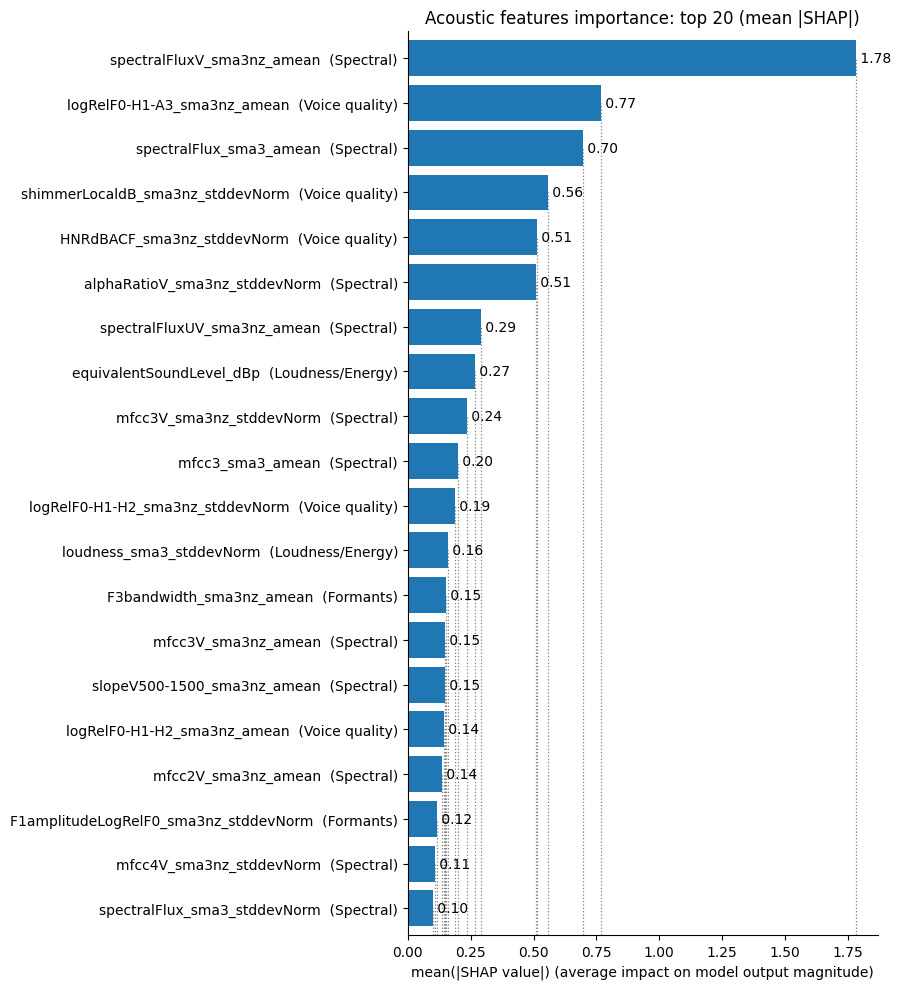

In [19]:
# SHAP plot for top 20 acoustic features (with category appended to labels)
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[ACOUSTIC]
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)

TOP_N = 20
order = np.argsort(mean_abs)[-TOP_N:]
top_cols = np.array(X.columns)[order]
feats = [f"{c}  ({categorize(c)})" for c in top_cols]   # <-- append category to each label
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title(f"Acoustic features importance: top {TOP_N} (mean |SHAP|)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"acoustic_top{TOP_N}_shap_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [20]:
# source: the original GeMAPS paper (Eyben et al., 2016)
# Perturbation measures (jitter + shimmer) grouped with HNR under "Voice quality",
# following common practice in affective-speech research.
import numpy as np
import pandas as pd

categories = pd.Series({c: categorize(c) for c in X_acoustic.columns}, name="category")
print(categories.value_counts())          # sanity check: how many features per category

category
Spectral           33
Formants           18
Voice quality      10
Timing/Pauses       6
Loudness/Energy     3
Pitch               2
Name: count, dtype: int64


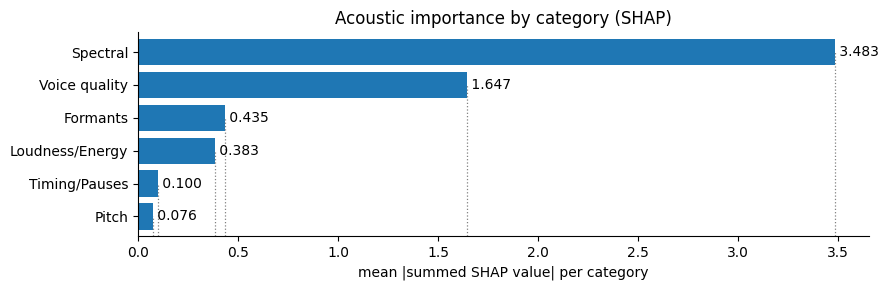

In [21]:
# SHAP values for the Random Forest model (acoustic values) grouped by category
import numpy as np, pandas as pd, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[ACOUSTIC]
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

sv_df = pd.DataFrame(sv, columns=X.columns)
cats = pd.Series({c: categorize(c) for c in X.columns})

# Sum SIGNED shap values within each category, per subject first (exact, via additivity)
cat_signed = sv_df.T.groupby(cats).sum().T   # rows = subjects, cols = categories

# THEN take mean absolute value across subjects
by_category = cat_signed.abs().mean(axis=0).sort_values(ascending=False)

names = by_category.index[::-1]        # largest on top
vals  = by_category.values[::-1]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(names))))
ax.barh(names, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)
    ax.text(v, i, f" {v:.3f}", va="center", ha="left", fontsize=10)
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

ax.set_xlabel("mean |summed SHAP value| per category")
ax.set_title("Acoustic importance by category (SHAP)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_acoustic_category_bar.png", dpi=300, bbox_inches="tight")
plt.show()


In [22]:
# Computing MDI and permutation importance for the Random Forest model (demo + acoustic values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_demoac = pd.concat([X_demo, X_acoustic], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_demoac, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  spectralFluxV_sma3nz_amean          0.235661
spectralFlux_sma3_amean             0.039632
F1amplitudeLogRelF0_sma3nz_amean    0.036618
F2frequency_sma3nz_stddevNorm       0.034936
logRelF0-H1-A3_sma3nz_amean         0.034897
                                      ...   
StddevUnvoicedSegmentLength         0.000869
mfcc1_sma3_amean                    0.000774
MeanVoicedSegmentLengthSec          0.000611
MeanUnvoicedSegmentLength           0.000349
gender                              0.000264
Length: 75, dtype: float64
Permutation Importances:  spectralFluxV_sma3nz_amean               0.124205
education_years                          0.054596
mfcc3V_sma3nz_stddevNorm                 0.042028
shimmerLocaldB_sma3nz_stddevNorm         0.039669
logRelF0-H1-A3_sma3nz_amean              0.029345
                                           ...   
F2frequency_sma3nz_stddevNorm           -0.013908
F1amplitudeLogRelF0_sma3nz_amean        -0.014264
mfcc3V_sma3nz_amean       

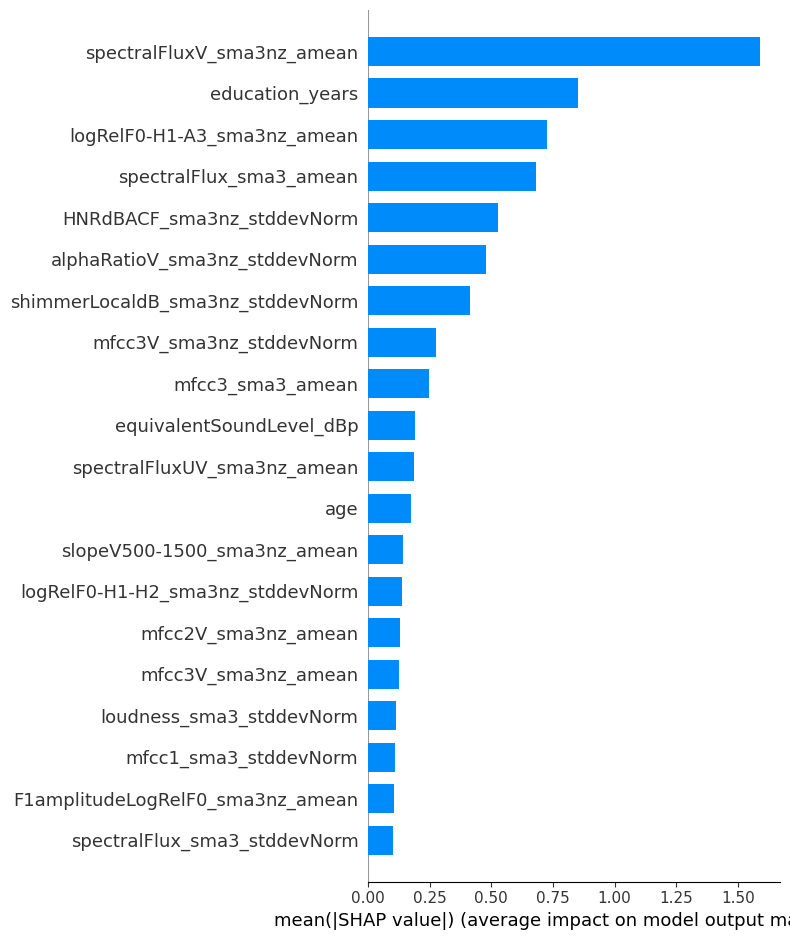

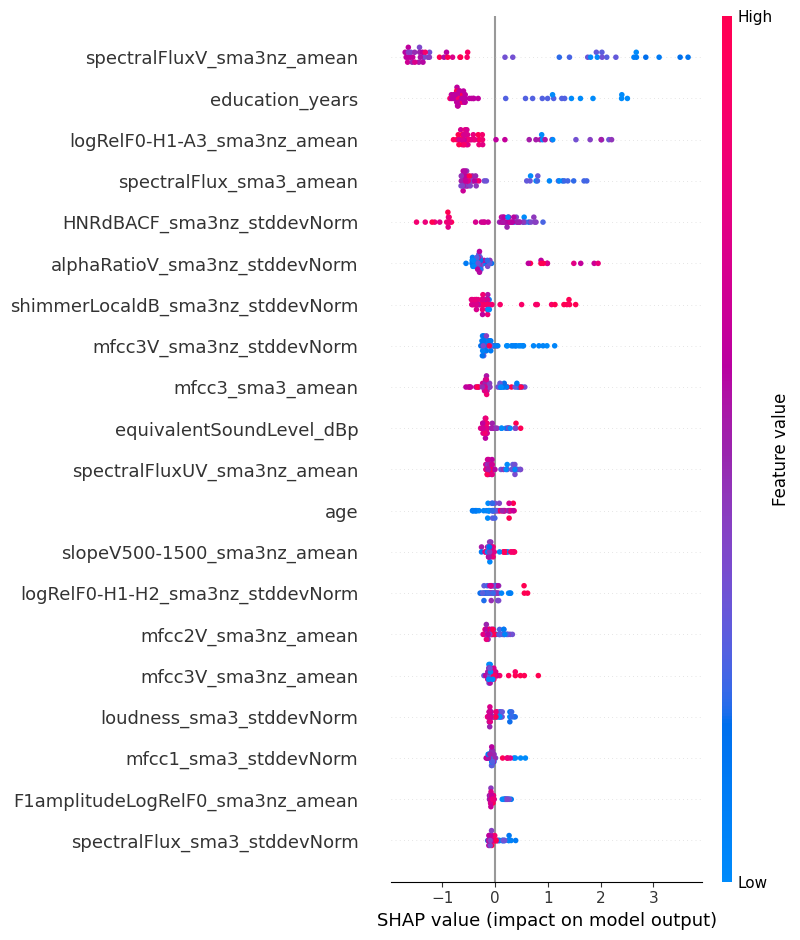

In [23]:
# SHAP for the Demographics + Acoustic Random Forest model
import shap

# Demographics + acoustic: exclude id, target, and the psych scales.
X_demoac = model_df[DEMO_ACOUSTIC]
y = model_df["phq9"]

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_demoac, y)
explainer = shap.TreeExplainer(rf)
shap_demoac = explainer.shap_values(X_demoac)                       # distinct name, not shap_values

shap.summary_plot(shap_demoac, X_demoac, plot_type="bar", max_display=20)  # global ranking (top 20)
shap.summary_plot(shap_demoac, X_demoac, max_display=20)                    # beeswarm: direction + magnitude


===== Demographics + Acoustic SHAP by category (corrected, additive) =====
                 mean_abs_shap_category  n_features
Spectral                         3.1778          33
Voice quality                    1.4393          10
education_years                  0.8527           1
Formants                         0.3987          18
Loudness/Energy                  0.3035           3
age                              0.1738           1
Timing/Pauses                    0.1177           6
Pitch                            0.0725           2
gender                           0.0004           1


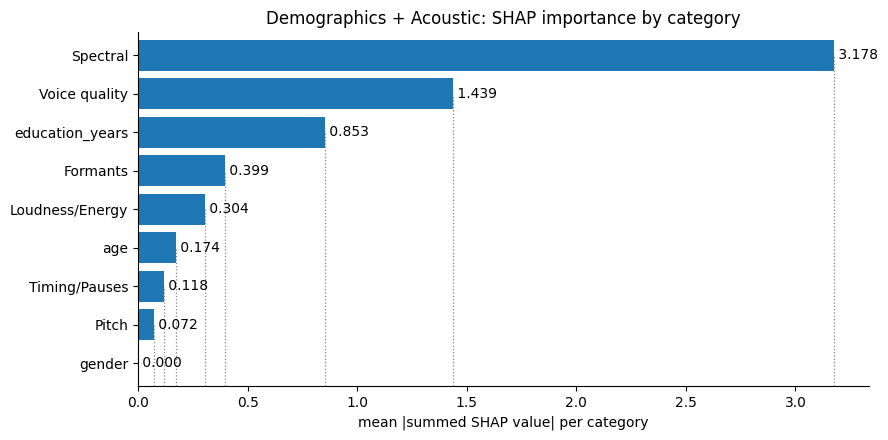

In [24]:
# SHAP for Demographics + Acoustic, aggregated by category
import re, numpy as np, pandas as pd, shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

def build_catmap(cols):
    non_acoustic = {"age", "gender", "education_years", "ctq_sf", "LES", "SSRS", "gad7", "PSQI"}
    return {c: (c if c in non_acoustic else categorize(c)) for c in cols}

def shap_by_category(name, X, y):
    rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
    shap_vals = shap.TreeExplainer(rf).shap_values(X)
    shap_df = pd.DataFrame(shap_vals, columns=X.columns)

    cat = pd.Series(build_catmap(X.columns))
    cat_signed = shap_df.T.groupby(cat).sum().T          # signed sum per subject (additive)
    by_cat = cat_signed.abs().mean(axis=0).sort_values(ascending=False)  # then mean |·|

    tbl = pd.DataFrame({
        "mean_abs_shap_category": by_cat.round(4),
        "n_features": cat.value_counts().reindex(by_cat.index),
    })
    print(f"\n===== {name} SHAP by category (corrected, additive) =====")
    print(tbl.to_string())

    # --- styled plot ---
    names = by_cat.index[::-1]        # largest on top
    vals  = by_cat.values[::-1]
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(names))))
    ax.barh(names, vals, color="#1f77b4")

    ymin = -0.6
    for i, v in enumerate(vals):
        ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)
        ax.text(v, i, f" {v:.3f}", va="center", ha="left", fontsize=10)
    ax.set_ylim(ymin, len(vals) - 0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax.set_xlabel("mean |summed SHAP value| per category")
    ax.set_title(f"{name}: SHAP importance by category")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"shap_{name.lower().replace(' ', '_').replace('+', 'plus')}_category_bar.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    return tbl

# --- run: Demographics + Acoustic ---
y = model_df["phq9"]
tbl_demoac = shap_by_category("Demographics + Acoustic", model_df[DEMO + ACOUSTIC], y)


In [25]:
# Computing MDI and permutation importance for the Random Forest combined model (clinical + acoustic values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_combined = pd.concat([X_clinical, X_acoustic], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  gad7                                     0.821067
mfcc3V_sma3nz_stddevNorm                 0.010289
mfcc4V_sma3nz_amean                      0.010242
spectralFlux_sma3_stddevNorm             0.009801
mfcc2V_sma3nz_stddevNorm                 0.008754
                                           ...   
F1amplitudeLogRelF0_sma3nz_stddevNorm    0.000268
StddevUnvoicedSegmentLength              0.000219
F1frequency_sma3nz_amean                 0.000204
F2bandwidth_sma3nz_stddevNorm            0.000127
gender                                   0.000060
Length: 79, dtype: float64
Permutation Importances:  gad7                               1.517472
mfcc4V_sma3nz_amean                0.006336
LES                                0.005460
mfcc4_sma3_stddevNorm              0.005449
age                                0.003351
                                     ...   
spectralFlux_sma3_amean           -0.002172
spectralFlux_sma3_stddevNorm      -0.002695
mfcc2V_sma3nz_stdde

In [26]:
# Grouped MDI + permutation importance: Demographics + Acoustic
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = model_df[DEMO + ACOUSTIC]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)

# acoustic -> its category; every non-acoustic (demo) feature stays as itself
cat_cols = {}
for feat in X.columns:
    key = categorize(feat) if feat in ACOUSTIC else feat     # <-- demo features individual
    cat_cols.setdefault(key, []).append(feat)

mdi = pd.Series(rf.feature_importances_, index=X.columns)

rng = np.random.RandomState(SEED)
baseline = r2_score(y_test, rf.predict(X_test))
N_REPEATS = 30

rows = []
for cat, cols in cat_cols.items():
    drops = []
    for _ in range(N_REPEATS):
        Xp = X_test.copy()
        idx = rng.permutation(len(Xp))
        Xp[cols] = X_test[cols].values[idx]          # block shuffle (single feature for demo, group for acoustic)
        drops.append(baseline - r2_score(y_test, rf.predict(Xp)))
    rows.append({
        "category": cat,
        "n_features": len(cols),
        "mdi_sum": round(mdi[cols].sum(), 4),
        "group_perm_mean": round(np.mean(drops), 4),
        "group_perm_std":  round(np.std(drops), 4),
    })

by_cat = pd.DataFrame(rows).set_index("category").sort_values("group_perm_mean", ascending=False)
print(by_cat.to_string())
by_cat.to_csv(CSV_DIR / "demoac_importance_by_category.csv")


                 n_features  mdi_sum  group_perm_mean  group_perm_std
category                                                             
Spectral                 33   0.5537           0.2678          0.1871
Voice quality            10   0.1308           0.1184          0.0655
education_years           1   0.0340           0.0697          0.0299
Loudness/Energy           3   0.0508           0.0046          0.0278
Pitch                     2   0.0180           0.0035          0.0087
age                       1   0.0159           0.0025          0.0061
gender                    1   0.0003          -0.0001          0.0008
Timing/Pauses             6   0.0128          -0.0124          0.0106
Formants                 18   0.1836          -0.0307          0.0548


In [27]:
# Grouped MDI + permutation importance: Clinical + Acoustic (clinical features kept individual)
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = model_df[CLINICAL + ACOUSTIC]                    # <-- clinical (7) + acoustic (72)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)

# acoustic -> its category; every non-acoustic (clinical) feature stays as itself
cat_cols = {}
for feat in X.columns:
    key = categorize(feat) if feat in ACOUSTIC else feat
    cat_cols.setdefault(key, []).append(feat)

mdi = pd.Series(rf.feature_importances_, index=X.columns)

rng = np.random.RandomState(SEED)
baseline = r2_score(y_test, rf.predict(X_test))
N_REPEATS = 30

rows = []
for cat, cols in cat_cols.items():
    drops = []
    for _ in range(N_REPEATS):
        Xp = X_test.copy()
        idx = rng.permutation(len(Xp))
        Xp[cols] = X_test[cols].values[idx]
        drops.append(baseline - r2_score(y_test, rf.predict(Xp)))
    rows.append({
        "category": cat,
        "n_features": len(cols),
        "mdi_sum": round(mdi[cols].sum(), 4),
        "group_perm_mean": round(np.mean(drops), 4),
        "group_perm_std":  round(np.std(drops), 4),
    })

by_cat = pd.DataFrame(rows).set_index("category").sort_values("group_perm_mean", ascending=False)
print(by_cat.to_string())
by_cat.to_csv(CSV_DIR / "clinac_importance_by_category.csv")   # <-- new filename


                 n_features  mdi_sum  group_perm_mean  group_perm_std
category                                                             
gad7                      1   0.8211           1.6672          0.5132
LES                       1   0.0057           0.0061          0.0038
age                       1   0.0059           0.0053          0.0027
ctq_sf                    1   0.0009           0.0013          0.0004
Formants                 18   0.0158           0.0009          0.0038
education_years           1   0.0010           0.0004          0.0003
gender                    1   0.0001           0.0003          0.0001
Spectral                 33   0.0987          -0.0002          0.0080
Pitch                     2   0.0103          -0.0006          0.0018
SSRS                      1   0.0013          -0.0008          0.0007
Timing/Pauses             6   0.0068          -0.0022          0.0015
Loudness/Energy           3   0.0066          -0.0031          0.0023
Voice quality       

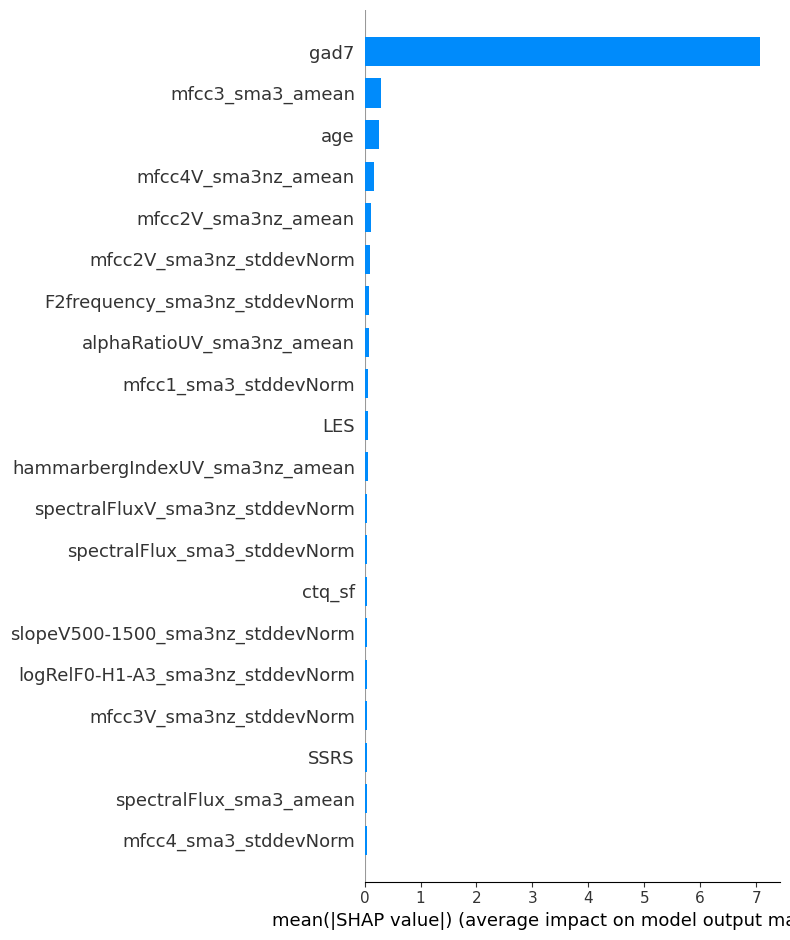

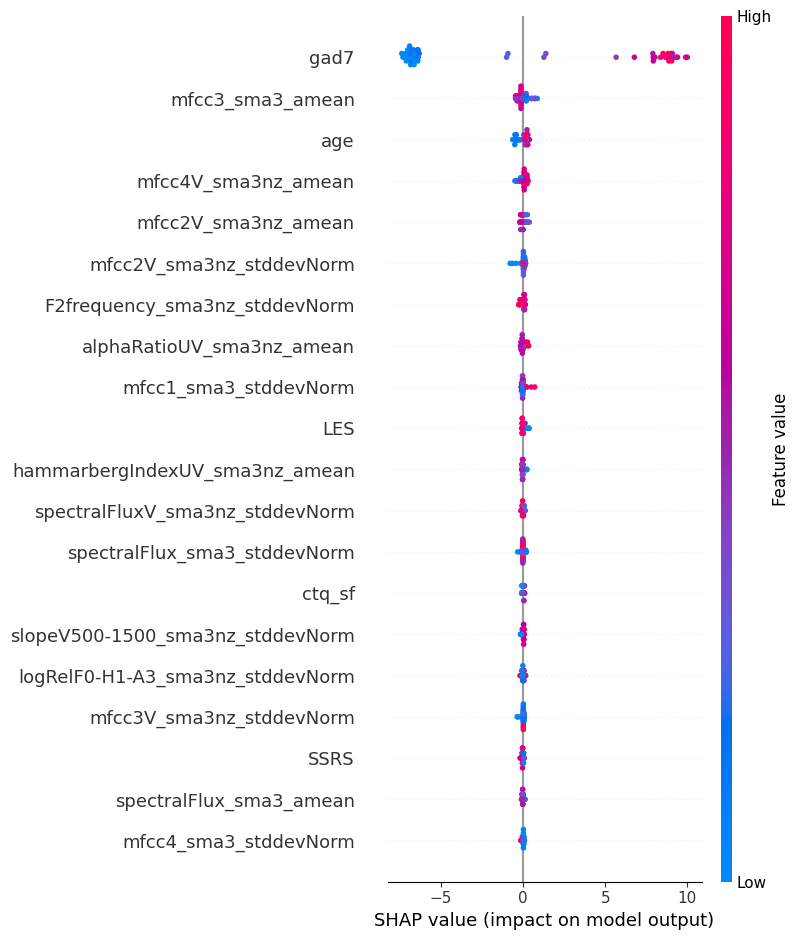

In [28]:
# SHAP for the combined Clinical + Acoustic Random Forest model
import shap

# Combined feature set: everything except the id and the target (clinical + acoustic = 95 features).
X_combined = model_df[CLINICAL_ACOUSTIC]
y = model_df["phq9"]

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_combined, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_combined)

shap.summary_plot(shap_values, X_combined, plot_type="bar", max_display=20)  # global ranking (top 20)
shap.summary_plot(shap_values, X_combined, max_display=20)                    # beeswarm: direction + magnitude



===== Clinical + Acoustic SHAP by category (corrected, additive) =====
                 mean_abs_shap_category  n_features
gad7                             7.0741           1
Spectral                         0.7132          33
age                              0.2617           1
Formants                         0.1499          18
Voice quality                    0.0903          10
LES                              0.0687           1
Timing/Pauses                    0.0615           6
ctq_sf                           0.0471           1
SSRS                             0.0442           1
Pitch                            0.0400           2
Loudness/Energy                  0.0273           3
education_years                  0.0227           1
gender                           0.0027           1


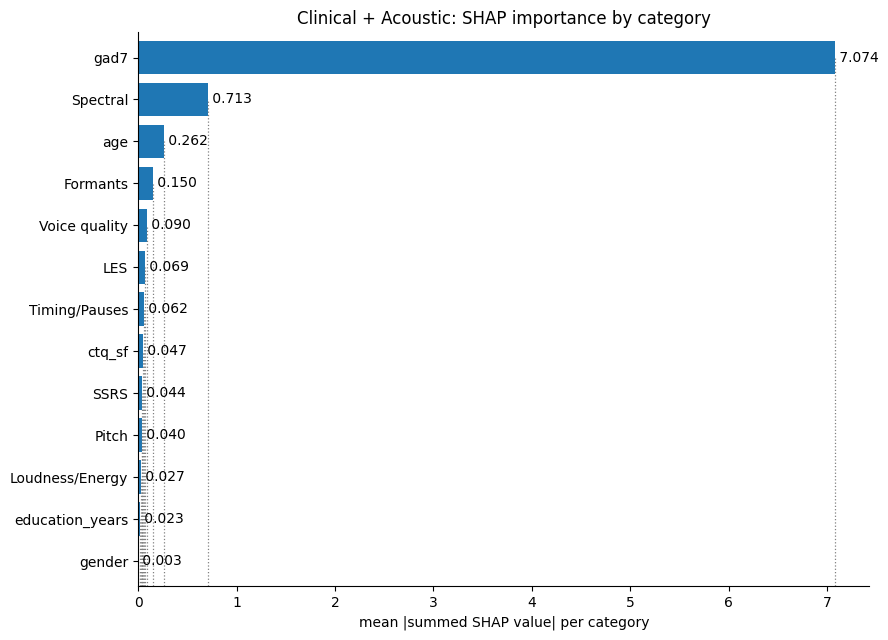

In [29]:
# SHAP for Clinical + Acoustic (combined), aggregated by category, reuses helpers from a previous cell
tbl_clinac = shap_by_category("Clinical + Acoustic", model_df[CLINICAL + ACOUSTIC], y)


In [30]:
# ===== Full SHAP log for the acoustic Random Forest model =====
import numpy as np, pandas as pd, shap
from sklearn.ensemble import RandomForestRegressor

# --- Rebuild the acoustic feature matrix (self-contained) ---
X_acoustic = model_df[ACOUSTIC]
y = model_df["phq9"]

# --- Fit + SHAP (named shap_acoustic so it won't be overwritten by other cells) ---
rf_acoustic   = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_acoustic, y)
explainer     = shap.TreeExplainer(rf_acoustic)
shap_acoustic = explainer.shap_values(X_acoustic)          # shape: (52 subjects, 88 features)
base_value    = explainer.expected_value                    # model's mean prediction
base_value = float(np.ravel(base_value)[0])   # array([9.4]) -> 9.4, and a plain float is fine too


# --- 1. FULL per-subject x per-feature SHAP matrix ---
shap_full = pd.DataFrame(shap_acoustic, columns=X_acoustic.columns, index=model_df.index)
shap_full.insert(0, "subject_id", model_df["subject_key"].values)
shap_full.insert(1, "phq9_true", y.values)
shap_full.insert(2, "phq9_pred", rf_acoustic.predict(X_acoustic))
shap_full.to_csv(CSV_DIR / "shap_acoustic_full.csv", index=False)

# --- 2. GLOBAL per-feature summary (ranked) ---
summary = pd.DataFrame({
    "feature":       X_acoustic.columns,
    "mean_abs_shap": np.abs(shap_acoustic).mean(axis=0),   # magnitude of influence
    "mean_shap":     shap_acoustic.mean(axis=0),           # average signed direction
    "std_shap":      shap_acoustic.std(axis=0),            # how much it varies across subjects
})
# attach categories if you defined categorize() earlier
if "categories" in dir():
    summary["category"] = summary["feature"].map(categories)
summary = summary.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
summary.insert(0, "rank", summary.index + 1)
summary.to_csv(CSV_DIR / "shap_acoustic_summary.csv", index=False)

# --- 3. Readable log to console ---
print(f"Model base value (mean prediction): {base_value:.3f}")
print(f"SHAP matrix: {shap_full.shape[0]} subjects x {X_acoustic.shape[1]} features\n")
print("Top 15 acoustic features by mean |SHAP|:")
print(summary.head(15).to_string(index=False))
print(f"\nSaved:\n  {CSV_DIR / 'shap_acoustic_full.csv'}  (full matrix)"
      f"\n  {CSV_DIR / 'shap_acoustic_summary.csv'}  (ranked summary)")


Model base value (mean prediction): 9.361
SHAP matrix: 52 subjects x 72 features

Top 15 acoustic features by mean |SHAP|:
 rank                          feature  mean_abs_shap  mean_shap  std_shap        category
    1       spectralFluxV_sma3nz_amean       1.780232  -0.049581  1.942076        Spectral
    2      logRelF0-H1-A3_sma3nz_amean       0.768437   0.005813  0.943376   Voice quality
    3          spectralFlux_sma3_amean       0.698579  -0.025832  0.791791        Spectral
    4 shimmerLocaldB_sma3nz_stddevNorm       0.559463   0.029156  0.769637   Voice quality
    5       HNRdBACF_sma3nz_stddevNorm       0.512726   0.000709  0.609997   Voice quality
    6    alphaRatioV_sma3nz_stddevNorm       0.508361   0.004033  0.669418        Spectral
    7      spectralFluxUV_sma3nz_amean       0.290187  -0.001663  0.319284        Spectral
    8         equivalentSoundLevel_dBp       0.268565  -0.083604  0.278408 Loudness/Energy
    9         mfcc3V_sma3nz_stddevNorm       0.236315   0.

In [31]:
# ===== Full-SHAP logger for all feature sets =====
import numpy as np, pandas as pd, shap
from sklearn.ensemble import RandomForestRegressor

def shap_log(name, X, y, category_map=None, top=15):
    """Fit an RF, compute SHAP, and write a full matrix + ranked summary for feature set `name`."""
    rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
    explainer  = shap.TreeExplainer(rf)
    shap_vals  = explainer.shap_values(X)
    base_value = float(np.ravel(explainer.expected_value)[0])   # scalar-safe

    # 1. Full per-subject x per-feature matrix
    full = pd.DataFrame(shap_vals, columns=X.columns, index=model_df.index)
    full.insert(0, "subject_id", model_df["subject_key"].values)
    full.insert(1, "phq9_true", y.values)
    full.insert(2, "phq9_pred", rf.predict(X))
    full.to_csv(CSV_DIR / f"shap_{name}_full.csv", index=False)

    # 2. Ranked global summary
    summary = pd.DataFrame({
        "feature":       X.columns,
        "mean_abs_shap": np.abs(shap_vals).mean(axis=0),
        "mean_shap":     shap_vals.mean(axis=0),
        "std_shap":      shap_vals.std(axis=0),
    })
    if category_map is not None:
        summary["category"] = summary["feature"].map(category_map)
    summary = summary.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    summary.insert(0, "rank", summary.index + 1)
    summary.to_csv(CSV_DIR / f"shap_{name}_summary.csv", index=False)

    # 3. Console log
    print(f"\n===== {name.upper()} =====")
    print(f"Base value (mean prediction): {base_value:.3f}")
    print(f"Matrix: {full.shape[0]} subjects x {X.shape[1]} features")
    assert np.allclose(base_value + shap_vals.sum(axis=1), rf.predict(X))   # consistency check
    print(summary.head(top).to_string(index=False))
    return summary

# --- Feature-set definitions ---
demo     = DEMO
psych    = PSYCH
clinical = CLINICAL
acoustic = ACOUSTIC
y = model_df["phq9"]

feature_sets = {
    "demo":              demo,
    "psych":             psych,
    "clinical":          clinical,
    "acoustic":          acoustic,
    "demo_acoustic":     demo + acoustic,
    "clinical_acoustic": clinical + acoustic,   # fully combined (95 features)
}

shap_summaries = {}
for name, cols in feature_sets.items():
    top = len(cols) if len(cols) <= 8 else 15   # show all for small sets, top-15 for big ones
    shap_summaries[name] = shap_log(name, model_df[cols], y, top=top)




===== DEMO =====
Base value (mean prediction): 9.361
Matrix: 52 subjects x 3 features
 rank         feature  mean_abs_shap  mean_shap  std_shap
    1 education_years       3.871771  -0.269664  4.919850
    2             age       2.799167   0.421085  3.501527
    3          gender       1.164202   0.037080  1.621306

===== PSYCH =====
Base value (mean prediction): 9.361
Matrix: 52 subjects x 4 features
 rank feature  mean_abs_shap  mean_shap  std_shap
    1    gad7       7.144796  -0.141353  7.486810
    2    SSRS       0.634127  -0.180739  0.840317
    3     LES       0.438360   0.114658  0.547063
    4  ctq_sf       0.273108   0.073972  0.350549

===== CLINICAL =====
Base value (mean prediction): 9.361
Matrix: 52 subjects x 7 features
 rank         feature  mean_abs_shap  mean_shap  std_shap
    1            gad7       7.088489  -0.014042  7.411446
    2            SSRS       0.557704  -0.155722  0.694167
    3             age       0.488993  -0.032082  0.570734
    4             LE

In [ ]:
# Consolidated interpretability export (MDI + SHAP + permutation)
#
# Two fits per feature set:
#   * rf_full  -> all 52 subjects. For MDI + SHAP. SHAP describes the behaviour of the fitted
#                 model, not its generalisation, so it is computed here. This
#                 makes shap_abs/shap_signed match the per-model SHAP cells
#                 and figures above.
#   * rf_split -> 41 train / 11 test. Permutation importance is only meaningful on data
#                 the model did not see. Matches the individual perm cells.
import numpy as np, pandas as pd, shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

feature_sets = {
    "Demographics":          DEMO,
    "Psych":                 PSYCH,
    "Clinical":              CLINICAL,
    "Acoustic":              ACOUSTIC,
    "Demographics+Acoustic": DEMO + ACOUSTIC,
    "Clinical+Acoustic":     CLINICAL + ACOUSTIC,
}

records = []
for sname, cols in feature_sets.items():
    X = model_df[cols]

    # --- SHAP: fit and explain on the full sample (all 52 subjects) ---
    rf_full   = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
    shap_vals = shap.TreeExplainer(rf_full).shap_values(X)

    # --- Permutation importance: held-out split (only meaningful out-of-sample) ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
    rf_split = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)
    perm = permutation_importance(rf_split, X_test, y_test, n_repeats=30,
                                  random_state=SEED, scoring="r2")

    df = pd.DataFrame({
        "model":        sname,
        "feature":      cols,
        "category":     [categorize(c) for c in cols],
        "mdi":          rf_full.feature_importances_,    # full sample (52)
        "shap_abs":     np.abs(shap_vals).mean(axis=0),  # full sample (52)
        "shap_signed":  shap_vals.mean(axis=0),          # full sample (52)
        "perm_mean":    perm.importances_mean,           # test set (11)
        "perm_sd":      perm.importances_std,
    })
    df = df.sort_values("shap_abs", ascending=False).reset_index(drop=True)
    df.insert(2, "rank_by_shap", df.index + 1)
    records.append(df)

interp = pd.concat(records, ignore_index=True).round(4)
interp.to_csv(CSV_DIR / "interpretability_all.csv", index=False)
print(f"Exported {len(interp)} feature-rows across {len(feature_sets)} models.")
print("MDI + SHAP: full sample (n=52) | permutation: test set (n=11)")
print(interp.groupby("model").head(3).to_string(index=False))
